In [1]:
# libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from matplotlib.colors import LinearSegmentedColormap

plt.style.use('ggplot')

from matplotlib.pyplot import figure
from matplotlib.lines import Line2D

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# reading the data
df = pd.read_csv(
    r'../data/df_compsize_wkmode_corr.csv'
)

In [3]:
# creating a contingency table
contingency_table = pd.crosstab(
    df['company_size_lb'],
    df['work_mode_lb']
)

print(contingency_table)

work_mode_lb     Flexible  Non-Flexible
company_size_lb                        
Large                 567          1021
Medium              17103         53007
Small                 162            53


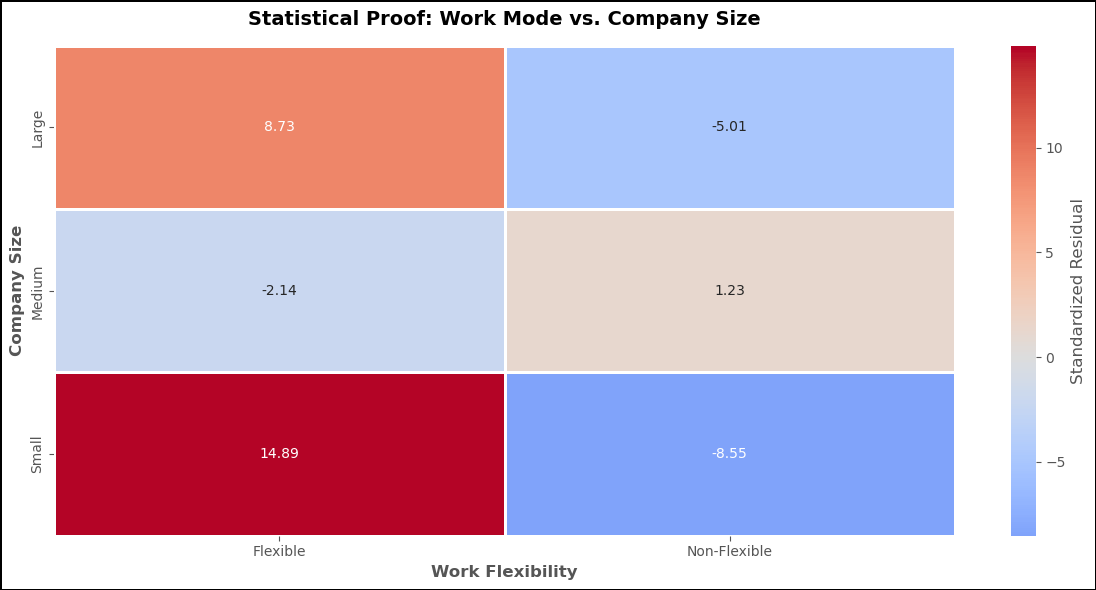

In [4]:
# percentage contingency table
chi2, p, dof, expected = chi2_contingency(contingency_table)

residuals = (contingency_table - expected) / np.sqrt(expected)

colors = ["#CC5A49", "#ffffff", "#4586AC"] 
my_custom_cmap = LinearSegmentedColormap.from_list("my_portfolio_cmap", colors)

plot = sns.heatmap(
    residuals,
    cmap = 'coolwarm',
    center = 0,
    annot = True,
    fmt = '.2f',
    linewidths = 1,
    linecolor = 'white',
    cbar_kws = {'label': 'Standardized Residual'}
)

plot.figure.patch.set_linewidth(1)
plot.figure.patch.set_edgecolor('black')

plt.title('Statistical Proof: Work Mode vs. Company Size', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Work Flexibility', fontsize=12, fontweight='bold')
plt.ylabel('Company Size', fontsize=12, fontweight='bold')

plt.tight_layout()

plt.savefig(
    r'plots/wkm_cs_heatmap.png',
    edgecolor = plot.figure.get_edgecolor(),
    facecolor = plot.figure.get_facecolor()
)

plt.show()